# DL_PR2 — Deep Learning Project 2 Solutions
## Adult Income Dataset — Complete Solutions for Tasks 1–7

> **Dataset note:** the uploaded CSV is used as the source of truth. Some approximate counts printed in the project sheet differ from this CSV version, so the notebook computes the actual values instead of hard-coding them.

## Task 1 — Data Loading, Cleaning & Exploratory Data Analysis

### Task 1.1 — Load and inspect the dataset

In [1]:
import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

df = pd.read_csv("adult.csv")
print("Initial shape:", df.shape)
display(df.head())

# Strip whitespace from every object column
obj_cols = df.select_dtypes(include=["object"]).columns
df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())

print("\nData types:")
display(df.dtypes)
print("\nShape after whitespace stripping:", df.shape)

Initial shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K



Data types:


age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object


Shape after whitespace stripping: (48842, 15)


### Task 1.2 — Handle missing values

In [2]:
df = df.replace("?", np.nan)

print("Missing values by column:")
display(df.isnull().sum())
print("Total missing values:", int(df.isnull().sum().sum()))
print("Rows with at least one missing value:",
      int(df.isnull().any(axis=1).sum()))

before = len(df)
df = df.dropna().copy()
print(f"Rows before dropna: {before:,}")
print(f"Rows after dropna:  {len(df):,}")
print(f"Rows removed:       {before-len(df):,}")

print("\nMissing values after cleaning:")
display(df.isnull().sum())

print("""
The project handout gives approximate missing-value counts, but the supplied
adult.csv is a different common version of the Adult dataset. Therefore these
values are intentionally calculated from the uploaded file.
""")

Missing values by column:


age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

Total missing values: 6465
Rows with at least one missing value: 3620
Rows before dropna: 48,842
Rows after dropna:  45,222
Rows removed:       3,620

Missing values after cleaning:


age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


The project handout gives approximate missing-value counts, but the supplied
adult.csv is a different common version of the Adult dataset. Therefore these
values are intentionally calculated from the uploaded file.



### Task 1.3 — Drop redundant columns

In [3]:
df = df.drop(columns=["fnlwgt"])
print("Shape after dropping fnlwgt:", df.shape)
display(df.head())

Shape after dropping fnlwgt: (45222, 14)


,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K


### Task 1.4 — Encode the target

Target counts:


income
0    34014
1    11208
Name: count, dtype: int64


Target proportions:


income
0    0.752156
1    0.247844
Name: proportion, dtype: float64

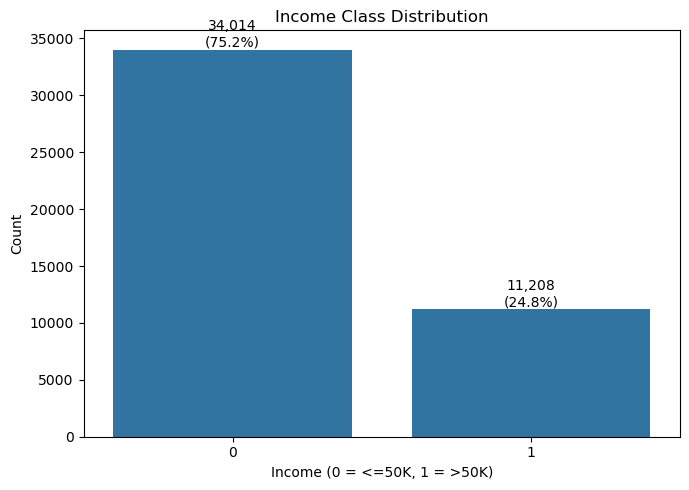


The dataset is imbalanced: class 0 is the majority and class 1 is the
minority. Accuracy alone can therefore be misleading.



In [4]:
df["income"] = (df["income"] == ">50K").astype(int)

print("Target counts:")
display(df["income"].value_counts())
print("\nTarget proportions:")
display(df["income"].value_counts(normalize=True).rename("proportion"))

plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x="income")
plt.title("Income Class Distribution")
plt.xlabel("Income (0 = <=50K, 1 = >50K)")
plt.ylabel("Count")
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / len(df)
    ax.annotate(f"{count:,}\n({pct:.1f}%)",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

print("""
The dataset is imbalanced: class 0 is the majority and class 1 is the
minority. Accuracy alone can therefore be misleading.
""")

### Task 1.5 — Exploratory visualisations

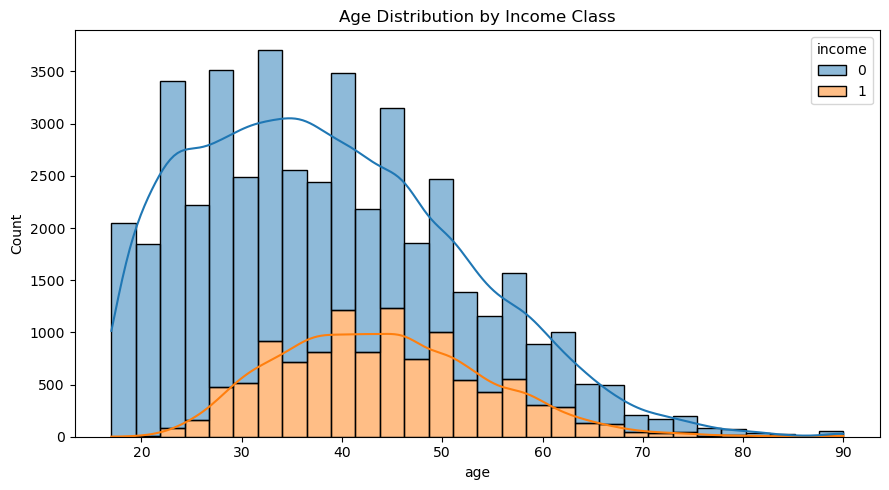

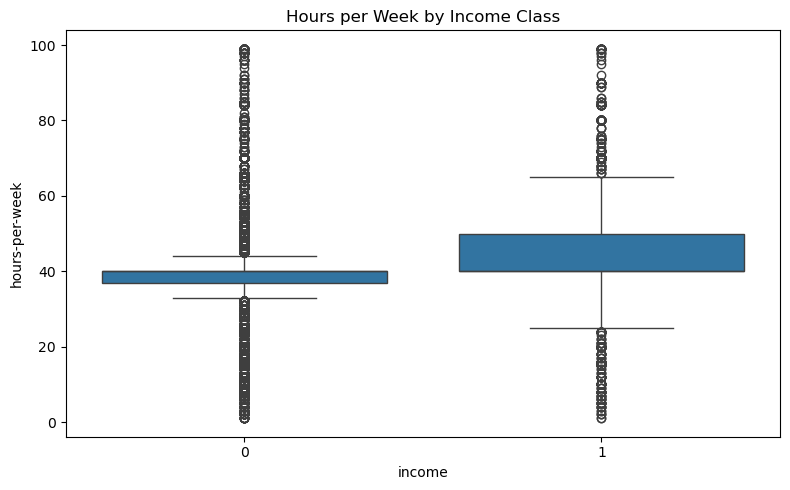

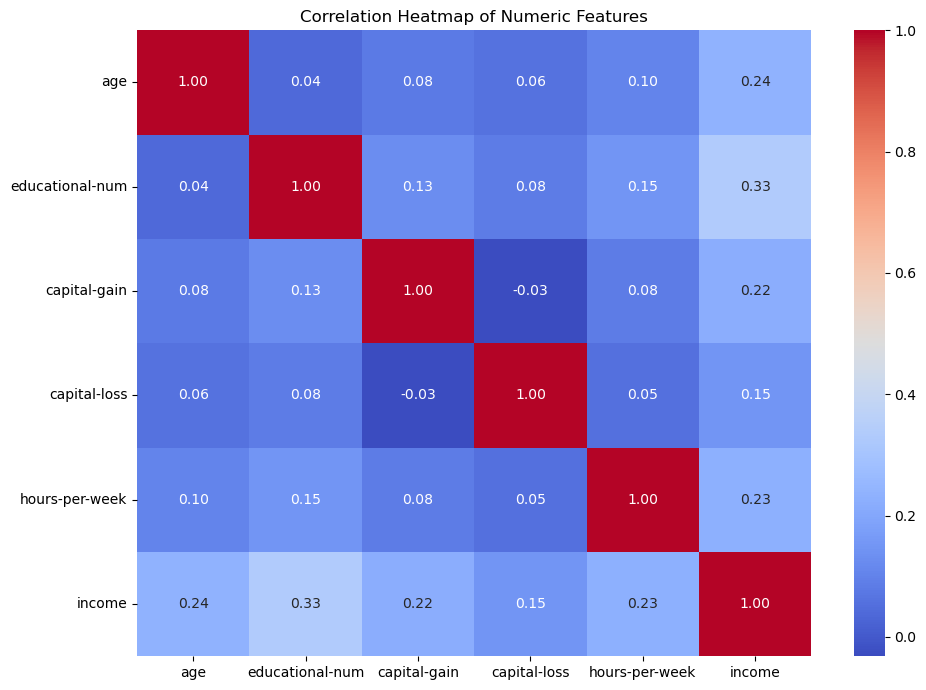

In [5]:
# (a) Age histogram coloured by income
plt.figure(figsize=(9,5))
sns.histplot(data=df, x="age", hue="income", bins=30, kde=True, multiple="stack")
plt.title("Age Distribution by Income Class")
plt.tight_layout()
plt.show()

# (b) Hours-per-week boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="income", y="hours-per-week")
plt.title("Hours per Week by Income Class")
plt.tight_layout()
plt.show()

# (c) Numeric correlation heatmap
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(10,7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

**Plot interpretations:** Higher-income observations tend to be older on average and often work more hours per week, although the classes overlap. The correlation heatmap shows linear relationships among numeric variables; weak pairwise correlation does not rule out useful non-linear interactions, which an ANN can learn.

### Task 1.6 — Encode categoricals, scale numeric columns, and split

In [6]:
X = df.drop(columns=["income"]).copy()
y = df["income"].copy()

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True).astype(float)

# Scale only the continuous numeric columns from the original feature table.
original_numeric = [
    c for c in df.drop(columns=["income"]).columns
    if pd.api.types.is_numeric_dtype(df[c])
]
numeric_after_encoding = [c for c in original_numeric if c in X.columns]

scaler = StandardScaler()
X[numeric_after_encoding] = scaler.fit_transform(X[numeric_after_encoding])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Encoded X shape:", X.shape)
print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

print("\nOverall class ratio:")
display(y.value_counts(normalize=True).rename("proportion"))
print("Train class ratio:")
display(y_train.value_counts(normalize=True).rename("proportion"))
print("Test class ratio:")
display(y_test.value_counts(normalize=True).rename("proportion"))

Encoded X shape: (45222, 95)
Train shapes: (36177, 95) (36177,)
Test shapes: (9045, 95) (9045,)

Overall class ratio:


income
0    0.752156
1    0.247844
Name: proportion, dtype: float64

Train class ratio:


income
0    0.752163
1    0.247837
Name: proportion, dtype: float64

Test class ratio:


income
0    0.752128
1    0.247872
Name: proportion, dtype: float64

## Common helper functions for Tasks 2–7

In [7]:
def build_ann(input_dim, hidden_units=(128,64), activation="relu",
              initializer="glorot_uniform", batch_norm=False):
    """Reusable ANN required by Task 2.1."""
    model = keras.Sequential(name="AdultIncomeANN")
    model.add(layers.Input(shape=(input_dim,)))
    for units in hidden_units:
        model.add(layers.Dense(units, activation=activation,
                               kernel_initializer=initializer))
        if batch_norm:
            model.add(layers.BatchNormalization())
    model.add(layers.Dense(1, activation="sigmoid",
                           kernel_initializer=initializer))
    return model

def compile_adam_bce(model, lr=0.001):
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

def evaluate_model(model, X_eval, y_eval, name="Model"):
    prob = model.predict(X_eval, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, pred),
        "Precision_1": precision_score(y_eval, pred, zero_division=0),
        "Recall_1": recall_score(y_eval, pred, zero_division=0),
        "F1_1": f1_score(y_eval, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_eval, prob)
    }
    return metrics, confusion_matrix(y_eval, pred), prob, pred

def plot_history(history, title):
    plt.figure(figsize=(8,5))
    plt.plot(history.history["accuracy"], label="Training accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=.2)
    plt.tight_layout()
    plt.show()

results = []
def add_result(model, name):
    out = evaluate_model(model, X_test, y_test, name)
    results.append(out[0])
    return out

def results_df():
    return pd.DataFrame(results)

# Task 2 — MLP Architecture — Baseline ANN

### Task 2.1 — Define the reusable `build_ann()` function

In [8]:
print("build_ann() created successfully.")
print("Default architecture: Dense(128) -> Dense(64) -> Dense(1)")

build_ann() created successfully.
Default architecture: Dense(128) -> Dense(64) -> Dense(1)


### Task 2.2 — Baseline ANN architecture

In [9]:
model_base = build_ann(
    X_train.shape[1],
    hidden_units=(128,64),
    activation="relu",
    initializer="glorot_uniform",
    batch_norm=False
)
compile_adam_bce(model_base)
model_base.summary()

Model: "AdultIncomeANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,609 (80.50 KB)

 Trainable params: 20,609 (80.50 KB)

 Non-trainable params: 0 (0.00 B)

### Task 2.3 — Train the baseline

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8422 - loss: 0.3408 - val_accuracy: 0.8485 - val_loss: 0.3219
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8537 - loss: 0.3150 - val_accuracy: 0.8499 - val_loss: 0.3204
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8556 - loss: 0.3106 - val_accuracy: 0.8499 - val_loss: 0.3200
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8572 - loss: 0.3070 - val_accuracy: 0.8499 - val_loss: 0.3193
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8586 - loss: 0.3038 - val_accuracy: 0.8521 - val_loss: 0.3191
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8609 - loss: 0.3005 - val_accuracy: 0.8507 - val_loss: 0.3194
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8623 - loss: 0.2976 - val_accuracy: 0.8505 - val_loss: 0.3201
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8642 - loss: 0.2944 - val_accuracy: 0.

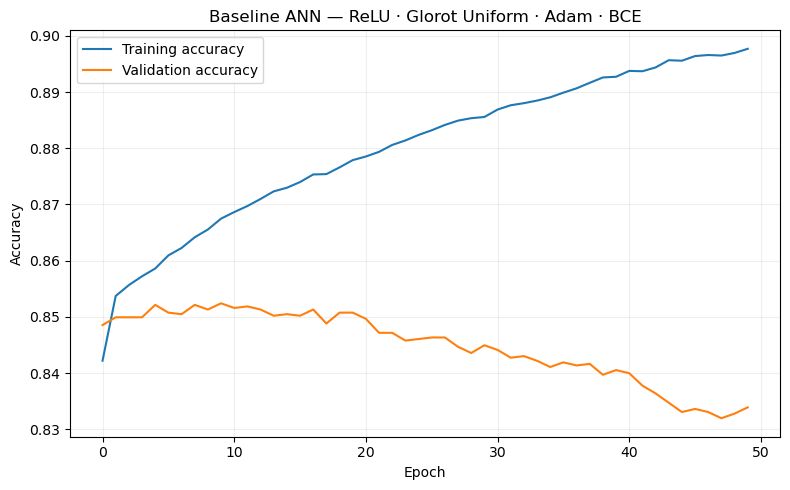

In [10]:
history_base = model_base.fit(
    X_train, y_train,
    epochs=50, batch_size=64,
    validation_split=0.1,
    verbose=1
)
plot_history(history_base,
             "Baseline ANN — ReLU · Glorot Uniform · Adam · BCE")

### Task 2.4 — Evaluate baseline with all metrics

,Model,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC
0,Baseline ANN,0.828082,0.674277,0.592774,0.630904,0.873081


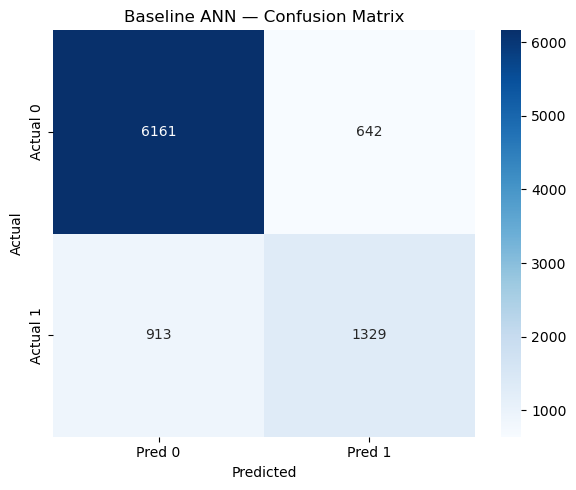

              precision    recall  f1-score   support

       <=50K       0.87      0.91      0.89      6803
        >50K       0.67      0.59      0.63      2242

    accuracy                           0.83      9045
   macro avg       0.77      0.75      0.76      9045
weighted avg       0.82      0.83      0.82      9045



In [11]:
base_metrics, base_cm, base_prob, base_pred = add_result(
    model_base, "Baseline ANN"
)
display(pd.DataFrame([base_metrics]))

plt.figure(figsize=(6,5))
sns.heatmap(base_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Baseline ANN — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(
    y_test, base_pred, target_names=["<=50K", ">50K"], zero_division=0
))

### Task 2.5 — WHY tabular data suits ANN

Adult Income is structured tabular data containing numeric and categorical predictors. After scaling and one-hot encoding, a feed-forward ANN can learn weighted combinations and non-linear interactions between variables such as age, education, occupation, marital status, capital gain/loss, and hours worked. A linear/logistic model cannot automatically learn these higher-order interactions without manual feature engineering. CNNs and RNNs are designed for spatial or sequential structure, which is not the natural structure of this dataset.

# Task 3 — Activation Functions — Comparison Experiment

### Task 3.1 — Train four models: ReLU, tanh, sigmoid, ELU

In [12]:
activation_models = {}
activation_histories = {}

for act in ["relu", "tanh", "sigmoid", "elu"]:
    print("\nTraining:", act)
    model = build_ann(X_train.shape[1], (128,64), act,
                      "glorot_uniform", False)
    compile_adam_bce(model)
    hist = model.fit(X_train, y_train, epochs=50, batch_size=64,
                     validation_split=0.1, verbose=1)
    activation_models[act] = model
    activation_histories[act] = hist
    add_result(model, f"Activation - {act}")


Training: relu
Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8392 - loss: 0.3400 - val_accuracy: 0.8480 - val_loss: 0.3223
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8545 - loss: 0.3140 - val_accuracy: 0.8502 - val_loss: 0.3208
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8569 - loss: 0.3097 - val_accuracy: 0.8485 - val_loss: 0.3199
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8577 - loss: 0.3062 - val_accuracy: 0.8496 - val_loss: 0.3197
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8592 - loss: 0.3030 - val_accuracy: 0.8491 - val_loss: 0.3197
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8608 - loss: 0.3001 - val_accuracy: 0.8491 - val_loss: 0.3197
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8626 - loss: 0.2971 - val_accuracy: 0.8494 - val_loss: 0.3202
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8638 - loss: 0.2941 - 

### Task 3.2 — Activation comparison 4-panel plot

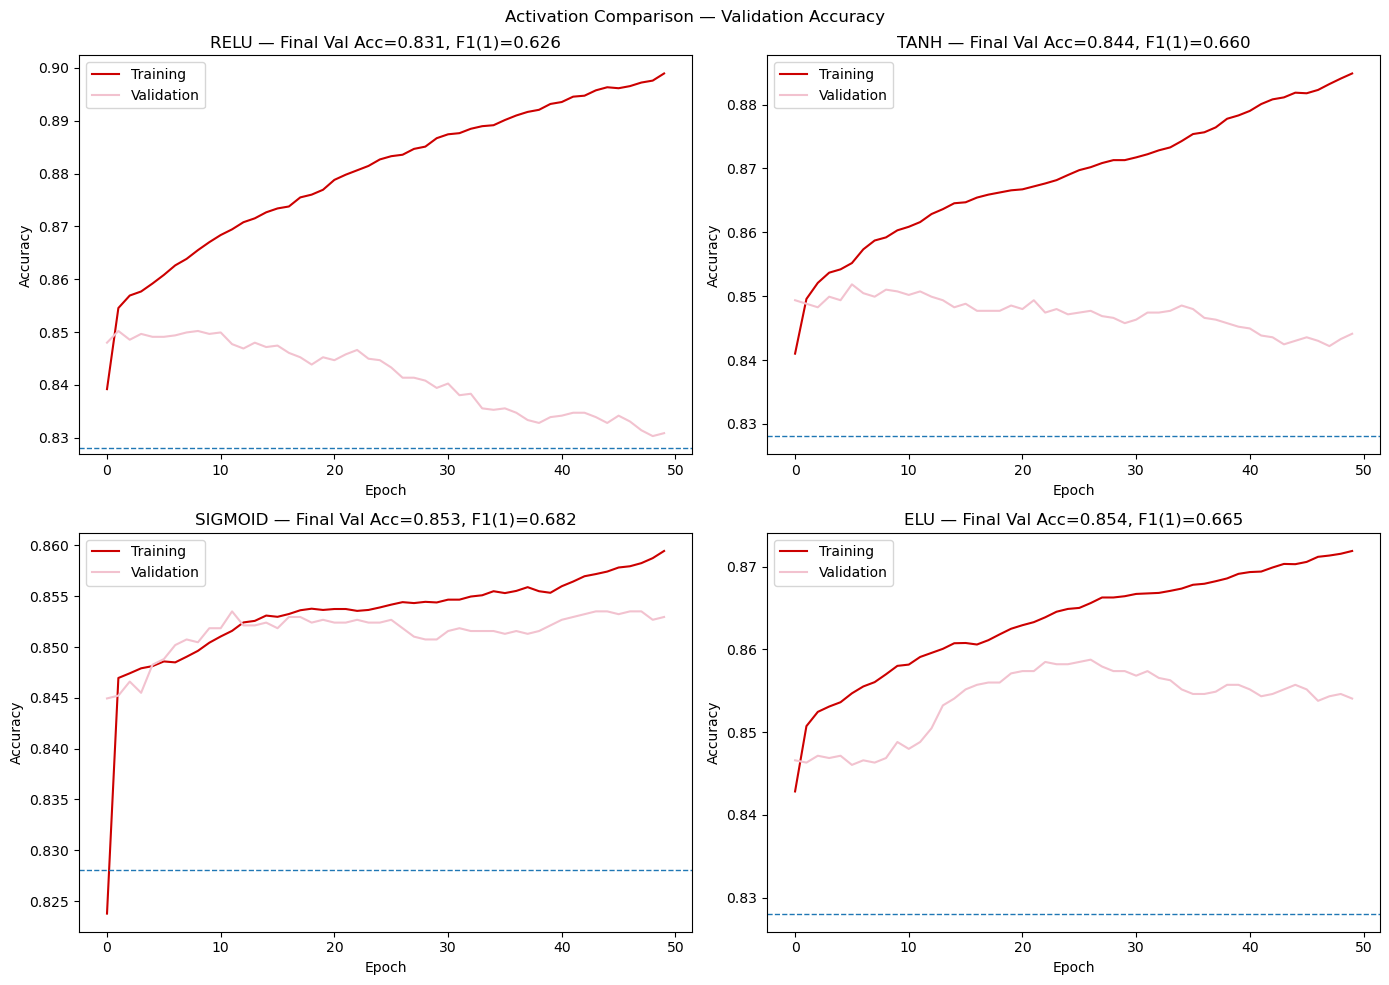

In [13]:
fig, axes = plt.subplots(2,2, figsize=(14,10))
for ax, act in zip(axes.ravel(), ["relu","tanh","sigmoid","elu"]):
    h = activation_histories[act].history
    ax.plot(h["accuracy"], color="#CC0000", label="Training")
    ax.plot(h["val_accuracy"], color="#F2C2CF", label="Validation")
    f1 = [r["F1_1"] for r in results if r["Model"] == f"Activation - {act}"][0]
    ax.set_title(f"{act.upper()} — Final Val Acc={h['val_accuracy'][-1]:.3f}, F1(1)={f1:.3f}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.axhline(base_metrics["Accuracy"], linestyle="--", linewidth=1)
    ax.legend()
plt.suptitle("Activation Comparison — Validation Accuracy")
plt.tight_layout()
plt.show()

### Task 3.3 — Dead-neuron check: ReLU

Activation matrix shape: (500, 128)
Mean dead-neuron fraction: 0.588390625
Neurons with >50% zero activations: 81


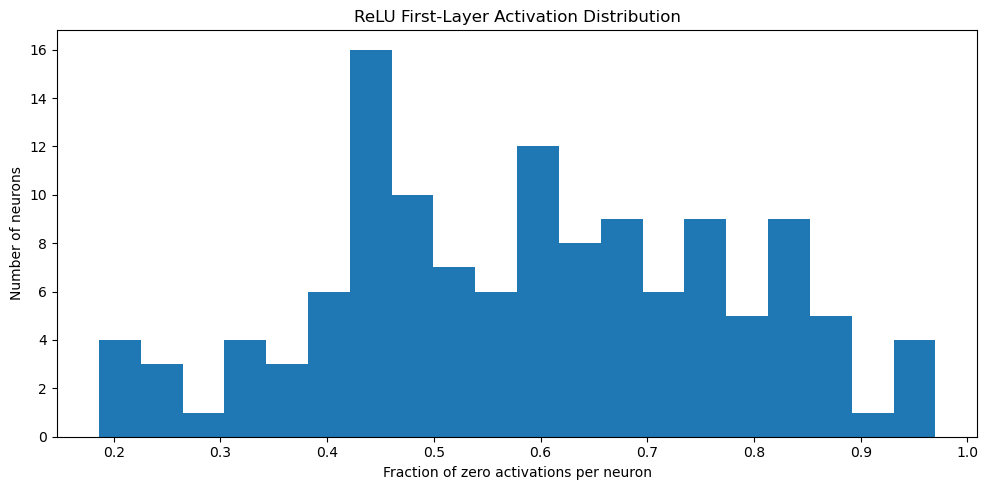

In [14]:
relu_model = activation_models["relu"]

# Make sure the model is built/called
_ = relu_model.predict(X_test.iloc[:1], verbose=0)

# Get Dense layers
dense_layers = [l for l in relu_model.layers if isinstance(l, layers.Dense)]

# First hidden Dense layer
first_hidden = dense_layers[0]

# Create intermediate model
intermediate = keras.Model(
    inputs=relu_model.inputs,
    outputs=first_hidden.output
)

# Get activations for first 500 test samples
act_out = intermediate.predict(
    X_test.iloc[:500],
    verbose=0
)

# Calculate fraction of zero activations
dead_fraction = np.mean(act_out <= 0, axis=0)

print("Activation matrix shape:", act_out.shape)
print("Mean dead-neuron fraction:", dead_fraction.mean())
print(
    "Neurons with >50% zero activations:",
    int((dead_fraction > 0.5).sum())
)

# Histogram
plt.figure(figsize=(10, 5))

plt.hist(dead_fraction, bins=20)

plt.title("ReLU First-Layer Activation Distribution")
plt.xlabel("Fraction of zero activations per neuron")
plt.ylabel("Number of neurons")

plt.tight_layout()
plt.show()

**Explanation:** ReLU is `f(x)=max(0,x)`. Negative pre-activations become zero, so a neuron can become inactive if it remains in the negative region. However, for positive inputs its derivative is 1, avoiding the severe saturation of sigmoid. This is why ReLU usually trains faster and has healthier gradient flow.

### Task 3.4 — Gradient flow check for hidden layers

,Weight,Gradient L2 norm
0,kernel,0.871642
1,bias,0.263214
2,kernel,0.322380
3,bias,0.080174
4,kernel,0.090490
5,bias,0.012152


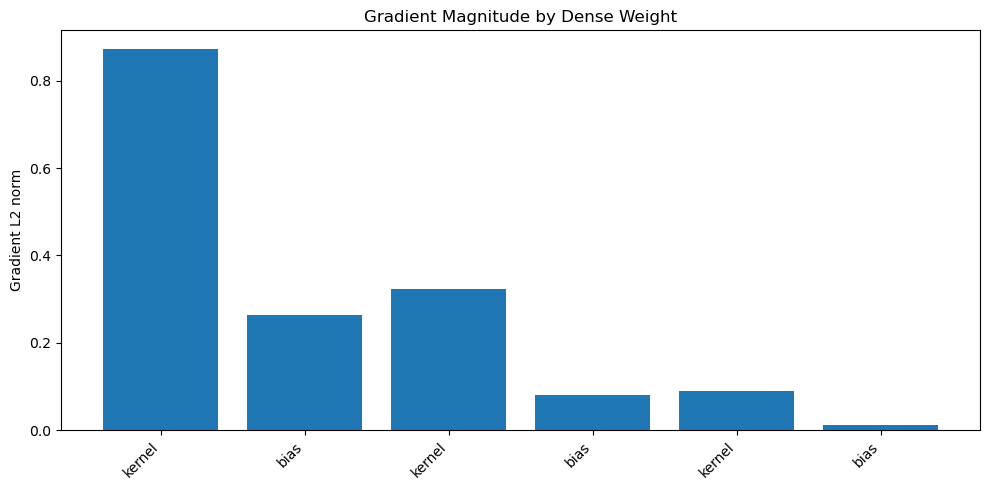

In [15]:
X_batch = tf.convert_to_tensor(X_train.iloc[:64].values, dtype=tf.float32)
y_batch = tf.convert_to_tensor(
    y_train.iloc[:64].values.reshape(-1,1), dtype=tf.float32
)

with tf.GradientTape() as tape:
    p = relu_model(X_batch, training=True)
    loss = tf.reduce_mean(keras.losses.binary_crossentropy(y_batch, p))

grads = tape.gradient(loss, relu_model.trainable_weights)

records = []
for w, g in zip(relu_model.trainable_weights, grads):
    if g is not None:
        records.append({"Weight": w.name, "Gradient L2 norm": float(tf.norm(g).numpy())})
grad_df = pd.DataFrame(records)
display(grad_df)

dense_grads, dense_names = [], []
for w, g in zip(relu_model.trainable_weights, grads):
    if g is not None and ("kernel" in w.name or "bias" in w.name):
        dense_grads.append(float(tf.norm(g).numpy()))
        dense_names.append(w.name)

plt.figure(figsize=(10,5))
plt.bar(range(len(dense_grads)), dense_grads)
plt.xticks(range(len(dense_grads)), dense_names, rotation=45, ha="right")
plt.title("Gradient Magnitude by Dense Weight")
plt.ylabel("Gradient L2 norm")
plt.tight_layout()
plt.show()

**Gradient explanation:** sigmoid has derivative `σ'(x)=σ(x)(1−σ(x))`, whose maximum is only 0.25. Across layers, repeated multiplication can shrink gradients. ReLU has derivative 1 on positive inputs, so active paths preserve gradients much better; only negative ReLU paths have zero derivative.

### Task 3.5 — Activation summary Markdown table

| Activation | Formula | Output Range | Zero-Centered | Main Gradient Risk | Recommendation |
|---|---|---|---|---|---|
| ReLU | `max(0,x)` | `[0,∞)` | No | Dead neurons | **Yes — hidden layers** |
| Tanh | `tanh(x)` | `[-1,1]` | Yes | Saturation / vanishing gradients | Sometimes |
| Sigmoid | `1/(1+e^-x)` | `(0,1)` | No | Strong saturation | Usually output only |
| ELU | `x` if `x>0`, else `α(e^x−1)` | `(-α,∞)` | Approximately | Less dead-neuron risk than ReLU | Good alternative |
| Sigmoid | `1/(1+e^-x)` | `(0,1)` | No | Saturation | **Yes — binary output** |

**Recommendation:** ReLU for hidden layers and sigmoid for the single binary output neuron.

# Task 4 — Weight Initialization Techniques

### Task 4.1 — Train five initializers

In [16]:
initializers = ["glorot_uniform","glorot_normal","he_uniform","he_normal","zeros"]
initializer_models = {}
initializer_histories = {}
initial_weights = {}
final_weights = {}

for init in initializers:
    print("\nTraining:", init)
    model = build_ann(X_train.shape[1], (128,64), "relu", init, False)
    compile_adam_bce(model)
    first_dense = next(l for l in model.layers if isinstance(l, layers.Dense))
    initial_weights[init] = first_dense.get_weights()[0].copy()

    hist = model.fit(X_train, y_train, epochs=50, batch_size=64,
                     validation_split=.1, verbose=1)
    initializer_models[init] = model
    initializer_histories[init] = hist
    final_weights[init] = first_dense.get_weights()[0].copy()
    add_result(model, f"Initializer - {init}")


Training: glorot_uniform
Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8435 - loss: 0.3364 - val_accuracy: 0.8458 - val_loss: 0.3208
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8537 - loss: 0.3150 - val_accuracy: 0.8474 - val_loss: 0.3188
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8553 - loss: 0.3106 - val_accuracy: 0.8483 - val_loss: 0.3183
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8574 - loss: 0.3071 - val_accuracy: 0.8491 - val_loss: 0.3182
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8593 - loss: 0.3041 - val_accuracy: 0.8496 - val_loss: 0.3177
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8604 - loss: 0.3010 - val_accuracy: 0.8507 - val_loss: 0.3172
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8618 - loss: 0.2981 - val_accuracy: 0.8507 - val_loss: 0.3170
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8633 - loss:

### Task 4.2 — WHY initialisation matters

All-zero initialization causes a **symmetry problem**: neurons in the same layer start with identical weights, produce identical outputs, receive identical gradients, and therefore remain identical. The layer cannot learn different features.

**Glorot/Xavier** initialization uses fan-in and fan-out to keep activation and gradient variance reasonably stable. **He** initialization uses approximately `2/fan_in`, which is especially appropriate for ReLU because half of a roughly symmetric input distribution can be clipped at zero. Good initialization prevents vanishing/exploding signals and gives optimization a useful starting point.

### Task 4.3 — Convergence speed comparison

glorot_uniform: first validation accuracy >=82% at epoch 1
glorot_normal: first validation accuracy >=82% at epoch 1
he_uniform: first validation accuracy >=82% at epoch 1
he_normal: first validation accuracy >=82% at epoch 1


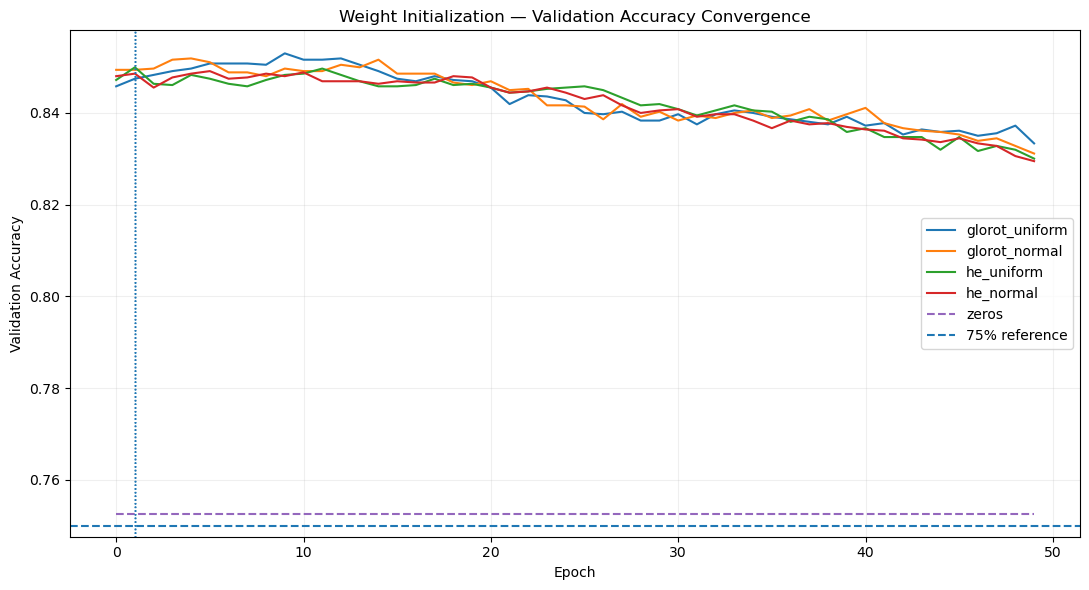

In [17]:
plt.figure(figsize=(11,6))
for init in initializers:
    vals = initializer_histories[init].history["val_accuracy"]
    plt.plot(vals, label=init, linestyle="--" if init=="zeros" else "-")

plt.axhline(.75, linestyle="--", linewidth=1.5, label="75% reference")
for init in initializers:
    if init != "zeros":
        vals = np.asarray(initializer_histories[init].history["val_accuracy"])
        hit = np.where(vals >= .82)[0]
        if len(hit):
            epoch = hit[0]+1
            plt.axvline(epoch, linestyle=":", linewidth=1)
            print(f"{init}: first validation accuracy >=82% at epoch {epoch}")
        else:
            print(f"{init}: did not reach 82% within 50 epochs")
plt.title("Weight Initialization — Validation Accuracy Convergence")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=.2)
plt.tight_layout()
plt.show()

### Task 4.4 — Zeros failure demonstration

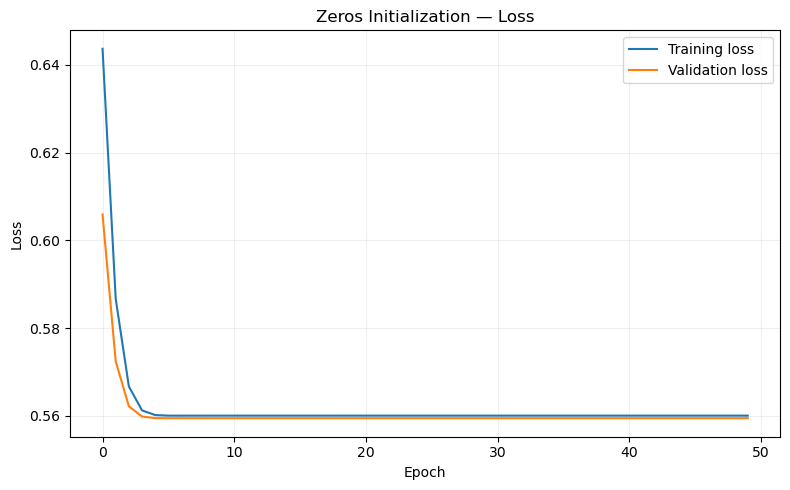

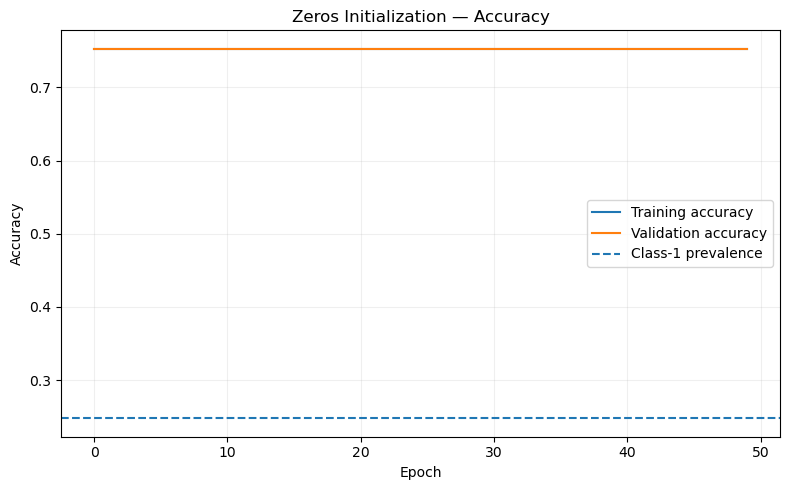

,Model,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC
0,Initializer - zeros,0.752128,0.0,0.0,0.0,0.5



The flat/majority-class-like behavior is the clearest demonstration of why
random, variance-aware initialization is necessary. Equal initial weights
prevent neurons from breaking symmetry and learning different features.



In [18]:
zh = initializer_histories["zeros"].history

plt.figure(figsize=(8,5))
plt.plot(zh["loss"], label="Training loss")
plt.plot(zh["val_loss"], label="Validation loss")
plt.title("Zeros Initialization — Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,5))
plt.plot(zh["accuracy"], label="Training accuracy")
plt.plot(zh["val_accuracy"], label="Validation accuracy")
plt.axhline(y_train.mean(), linestyle="--", label="Class-1 prevalence")
plt.title("Zeros Initialization — Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

zero_metrics = [r for r in results if r["Model"]=="Initializer - zeros"][0]
display(pd.DataFrame([zero_metrics]))

print("""
The flat/majority-class-like behavior is the clearest demonstration of why
random, variance-aware initialization is necessary. Equal initial weights
prevent neurons from breaking symmetry and learning different features.
""")

### Task 4.5 — Weight distribution visualisation

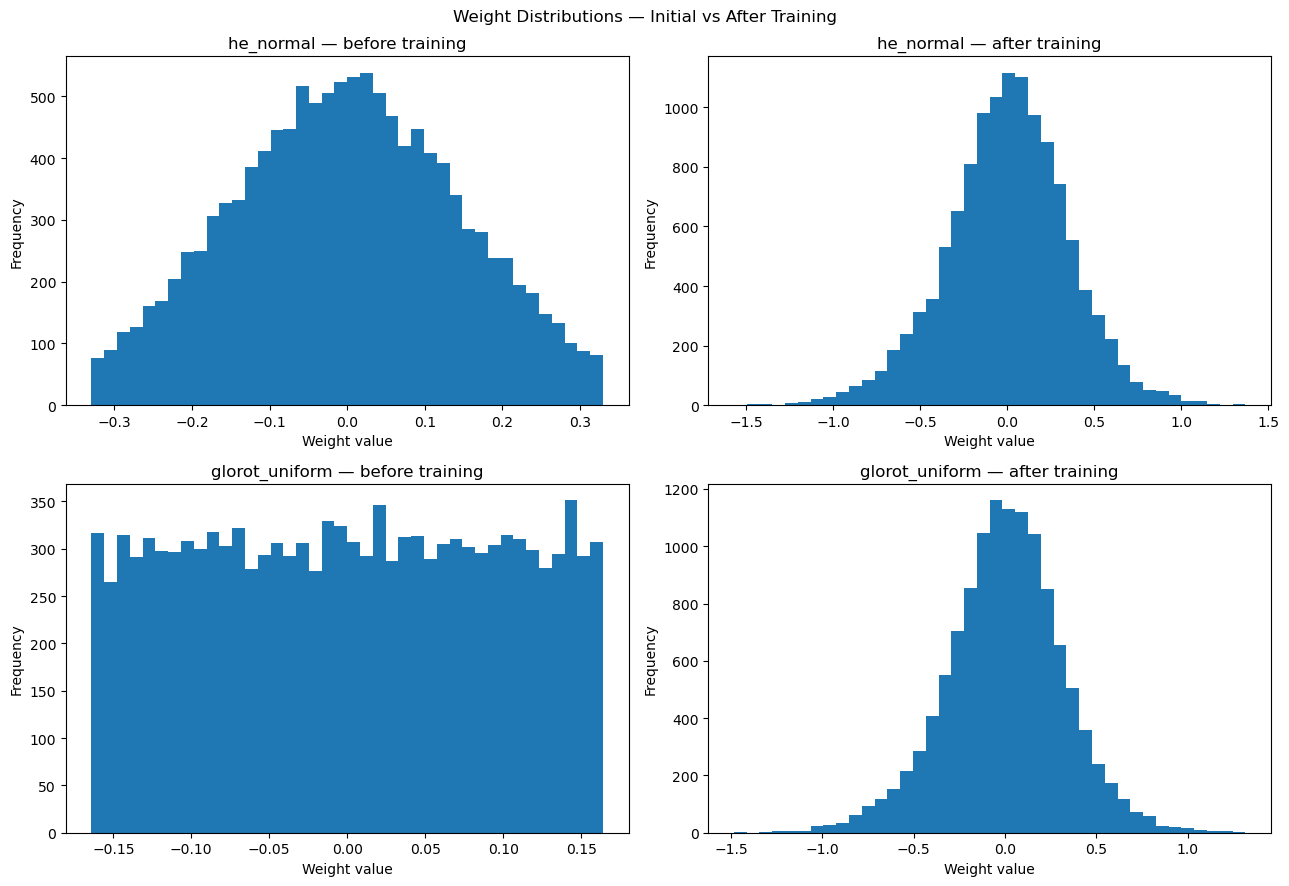


Before training the weights should be centered near zero with the variance
specified by the initializer. After training the distributions can shift and
spread because back-propagation has learned a useful parameter configuration.



In [19]:
fig, axes = plt.subplots(2,2, figsize=(13,9))
items = [
    ("he_normal","before"),
    ("he_normal","after"),
    ("glorot_uniform","before"),
    ("glorot_uniform","after")
]
for ax, (init, stage) in zip(axes.ravel(), items):
    w = initial_weights[init] if stage=="before" else final_weights[init]
    ax.hist(w.ravel(), bins=40)
    ax.set_title(f"{init} — {stage} training")
    ax.set_xlabel("Weight value")
    ax.set_ylabel("Frequency")
plt.suptitle("Weight Distributions — Initial vs After Training")
plt.tight_layout()
plt.show()

print("""
Before training the weights should be centered near zero with the variance
specified by the initializer. After training the distributions can shift and
spread because back-propagation has learned a useful parameter configuration.
""")

# Task 5 — Loss Functions

### Task 5.1 — Binary Cross-Entropy

For a binary target `y∈{0,1}` and sigmoid prediction `p`:

**`L = −[y log(p) + (1−y) log(1−p)]`**

BCE is the negative log-likelihood of a Bernoulli distribution. It directly matches a sigmoid output interpreted as a probability and heavily penalizes confident wrong predictions. Therefore it is the natural default loss for binary classification.

In [20]:
print("Baseline compiled loss:", model_base.loss)

Baseline compiled loss: binary_crossentropy


### Task 5.2 — MSE as a classification loss (wrong-tool experiment)

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8392 - loss: 0.1102 - val_accuracy: 0.8480 - val_loss: 0.1033
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8542 - loss: 0.1007 - val_accuracy: 0.8488 - val_loss: 0.1025
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8557 - loss: 0.0990 - val_accuracy: 0.8507 - val_loss: 0.1020
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8584 - loss: 0.0977 - val_accuracy: 0.8510 - val_loss: 0.1019
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8601 - loss: 0.0965 - val_accuracy: 0.8527 - val_loss: 0.1019
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8626 - loss: 0.0954 - val_accuracy: 0.8543 - val_loss: 0.1016
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8634 - loss: 0.0943 - val_accuracy: 0.8532 - val_loss: 0.1017
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8654 - loss: 0.0934 - val_accuracy: 0.

,Model,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC
0,MSE loss,0.826755,0.661252,0.617306,0.638524,0.881584


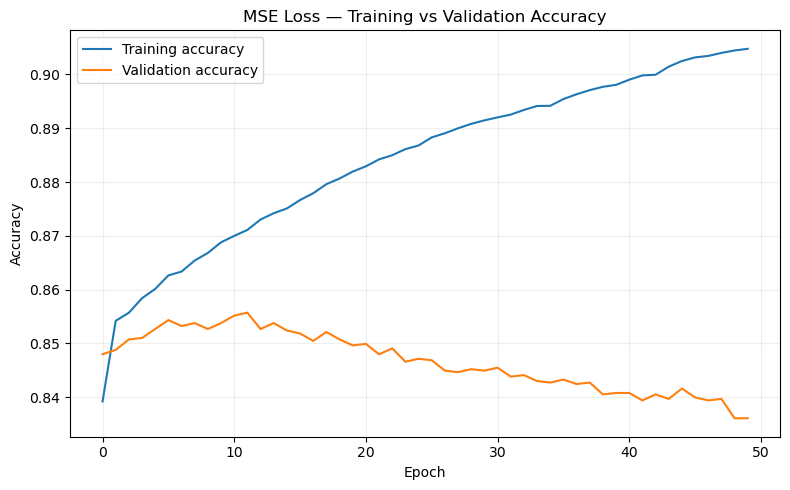


MSE is designed for continuous regression targets. With a sigmoid output its
gradient includes the sigmoid derivative p(1-p), which becomes tiny near 0
and 1. BCE is the natural Bernoulli likelihood and usually gives a stronger
classification learning signal.



In [21]:
model_mse = build_ann(X_train.shape[1], (128,64), "relu", "he_normal", False)
model_mse.compile(optimizer=keras.optimizers.Adam(.001),
                  loss="mean_squared_error", metrics=["accuracy"])

history_mse = model_mse.fit(
    X_train, y_train, epochs=50, batch_size=64,
    validation_split=.1, verbose=1
)
mse_metrics, mse_cm, mse_prob, mse_pred = add_result(model_mse, "MSE loss")
display(pd.DataFrame([mse_metrics]))
plot_history(history_mse, "MSE Loss — Training vs Validation Accuracy")

print("""
MSE is designed for continuous regression targets. With a sigmoid output its
gradient includes the sigmoid derivative p(1-p), which becomes tiny near 0
and 1. BCE is the natural Bernoulli likelihood and usually gives a stronger
classification learning signal.
""")

### Task 5.3 — Weighted BCE for class imbalance

In [22]:
classes = np.array([0,1])
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))
print("Class weights:", class_weight)

model_wbce = build_ann(X_train.shape[1], (128,64), "relu", "he_normal", False)
model_wbce.compile(optimizer=keras.optimizers.Adam(.001),
                   loss="binary_crossentropy", metrics=["accuracy"])

history_wbce = model_wbce.fit(
    X_train, y_train, epochs=50, batch_size=64,
    validation_split=.1, class_weight=class_weight, verbose=1
)
wbce_metrics, wbce_cm, wbce_prob, wbce_pred = add_result(
    model_wbce, "Weighted BCE"
)
display(pd.DataFrame([wbce_metrics]))
display(pd.DataFrame(wbce_cm,
                     index=["Actual 0","Actual 1"],
                     columns=["Pred 0","Pred 1"]))

Class weights: {np.int64(0): np.float64(0.6647495498144133), np.int64(1): np.float64(2.0174548293553425)}
Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8013 - loss: 0.3952 - val_accuracy: 0.8051 - val_loss: 0.3895
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8098 - loss: 0.3712 - val_accuracy: 0.8082 - val_loss: 0.3824
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8135 - loss: 0.3651 - val_accuracy: 0.8068 - val_loss: 0.3813
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8159 - loss: 0.3601 - val_accuracy: 0.8074 - val_loss: 0.3798
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8194 - loss: 0.3555 - val_accuracy: 0.8071 - val_loss: 0.3799
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8226 - loss: 0.3510 - val_accuracy: 0.8062 - val_loss: 0.3794
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8246 - loss: 0.3466 - val_accuracy: 0.8051 - val_loss: 0.380

,Model,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC
0,Weighted BCE,0.798231,0.570991,0.747993,0.647615,0.873434


,Pred 0,Pred 1
Actual 0,5543,1260
Actual 1,565,1677


### Task 5.4 — Focal Loss

In [23]:
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        ce = -(y_true*tf.math.log(y_pred) +
               (1-y_true)*tf.math.log(1-y_pred))
        p_t = y_true*y_pred + (1-y_true)*(1-y_pred)
        alpha_t = y_true*alpha + (1-y_true)*(1-alpha)
        weight = alpha_t * tf.pow(1-p_t, gamma)
        return tf.reduce_mean(weight*ce)
    return loss_fn

model_focal = build_ann(X_train.shape[1], (128,64), "relu", "he_normal", False)
model_focal.compile(optimizer=keras.optimizers.Adam(.001),
                    loss=focal_loss(2.0, .25), metrics=["accuracy"])

history_focal = model_focal.fit(
    X_train, y_train, epochs=50, batch_size=64,
    validation_split=.1, verbose=1
)
focal_metrics, focal_cm, focal_prob, focal_pred = add_result(
    model_focal, "Focal Loss"
)
display(pd.DataFrame([focal_metrics]))

print("""
Focal loss multiplies BCE by a factor based on (1-p_t)^gamma. Easy,
high-confidence examples receive less weight, while hard examples receive
more emphasis. This is useful when minority/hard cases are important.
""")

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8133 - loss: 0.0359 - val_accuracy: 0.8181 - val_loss: 0.0332
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8283 - loss: 0.0325 - val_accuracy: 0.8198 - val_loss: 0.0330
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8303 - loss: 0.0319 - val_accuracy: 0.8212 - val_loss: 0.0330
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8322 - loss: 0.0315 - val_accuracy: 0.8214 - val_loss: 0.0330
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8343 - loss: 0.0311 - val_accuracy: 0.8228 - val_loss: 0.0330
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8358 - loss: 0.0307 - val_accuracy: 0.8228 - val_loss: 0.0329
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8382 - loss: 0.0303 - val_accuracy: 0.8242 - val_loss: 0.0330
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8401 - loss: 0.0299 - val_accuracy: 0.

,Model,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC
0,Focal Loss,0.81581,0.7066,0.43934,0.541804,0.867987



Focal loss multiplies BCE by a factor based on (1-p_t)^gamma. Easy,
high-confidence examples receive less weight, while hard examples receive
more emphasis. This is useful when minority/hard cases are important.



### Task 5.5 — Loss function summary table

In [24]:
loss_summary = pd.DataFrame([
    ["Binary Cross-Entropy", "-[y log(p)+(1-y)log(1-p)]",
     "Standard binary classification", "No", base_metrics["F1_1"], "Default baseline"],
    ["Weighted BCE", "-w_y[y log(p)+(1-y)log(1-p)]",
     "Imbalanced binary classification", "Yes", wbce_metrics["F1_1"], "Strong choice here"],
    ["MSE", "(y-p)^2", "Regression", "No", mse_metrics["F1_1"], "Not preferred"],
    ["Focal Loss", "-alpha(1-p_t)^gamma log(p_t)",
     "Hard-example / imbalance handling", "Yes", focal_metrics["F1_1"], "Use if F1 improves"]
], columns=["Loss Function","Formula (simplified)","Best For",
            "Imbalance Handling","Class 1 F1","Recommendation"])
display(loss_summary)

,Loss Function,Formula (simplified),Best For,Imbalance Handling,Class 1 F1,Recommendation
0,Binary Cross-Entropy,-[y log(p)+(1-y)log(1-p)],Standard binary classification,No,0.630904,Default baseline
1,Weighted BCE,-w_y[y log(p)+(1-y)log(1-p)],Imbalanced binary classification,Yes,0.647615,Strong choice here
2,MSE,(y-p)^2,Regression,No,0.638524,Not preferred
3,Focal Loss,-alpha(1-p_t)^gamma log(p_t),Hard-example / imbalance handling,Yes,0.541804,Use if F1 improves


# Task 6 — Batch Normalization

### Task 6.1 — Build ANN with Batch Normalization

In [25]:
model_bn = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, kernel_initializer="he_normal"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dense(64, kernel_initializer="he_normal"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dense(1, activation="sigmoid")
])
model_bn.compile(optimizer=keras.optimizers.Adam(.001),
                 loss="binary_crossentropy", metrics=["accuracy"])
model_bn.summary()
print("""
Each BatchNorm feature has gamma and beta as trainable parameters plus
moving_mean and moving_variance used for inference.
""")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 128)            │        12,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,377 (83.50 KB)

 Trainable params: 20,993 (82.00 KB)

 Non-trainable params: 384 (1.50 KB)


Each BatchNorm feature has gamma and beta as trainable parameters plus
moving_mean and moving_variance used for inference.



### Task 6.2 — WHY Batch Normalization

During training, layer inputs can shift as preceding weights change. BatchNorm normalizes a mini-batch and then learns a scale and shift:

**`BN(x)=gamma * ((x-mu_B)/sqrt(sigma_B^2+epsilon)) + beta`**

This can stabilize activation scales, improve gradient flow, make optimization less sensitive to parameter scale, and often speed convergence. Moving statistics are used at inference time. Mini-batch statistics also add a small amount of noise that can act as mild regularization.

### Task 6.3 — Train and compare with/without BatchNorm

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8299 - loss: 0.3570 - val_accuracy: 0.8499 - val_loss: 0.3239
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8538 - loss: 0.3165 - val_accuracy: 0.8496 - val_loss: 0.3210
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8569 - loss: 0.3088 - val_accuracy: 0.8527 - val_loss: 0.3205
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8597 - loss: 0.3032 - val_accuracy: 0.8496 - val_loss: 0.3208
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8624 - loss: 0.2982 - val_accuracy: 0.8485 - val_loss: 0.3217
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8652 - loss: 0.2937 - val_accuracy: 0.8488 - val_loss: 0.3228
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8678 - loss: 0.2893 - val_accuracy: 0.8505 - val_loss: 0.3249
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8706 - loss: 0.2849 - val_accuracy: 0.

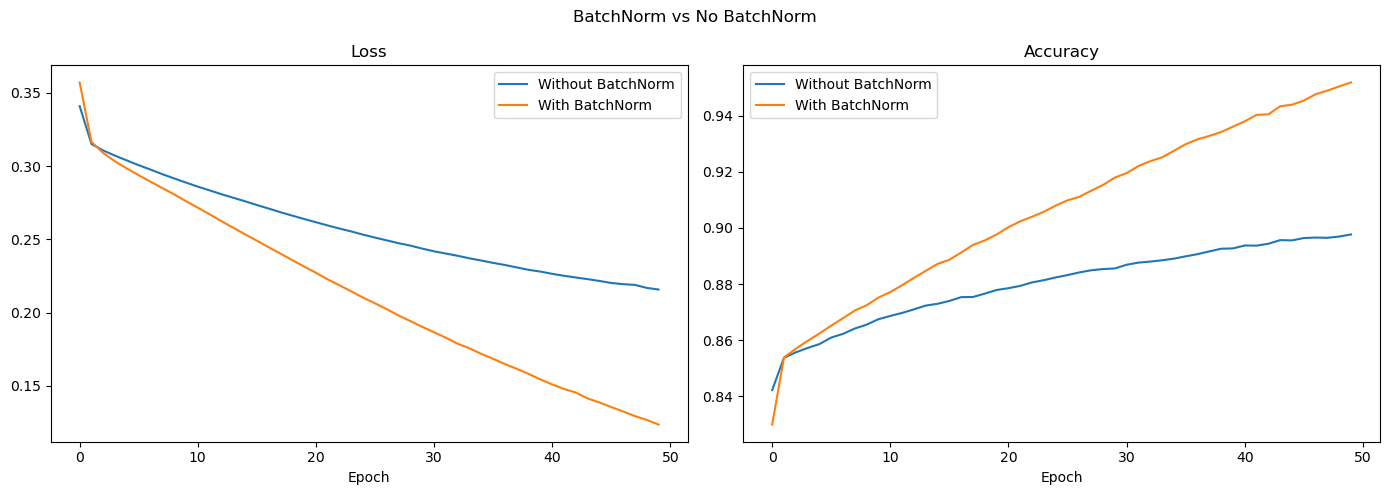

,Model,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC
0,Baseline ANN,0.828082,0.674277,0.592774,0.630904,0.873081
1,BatchNorm ANN,0.806191,0.624301,0.547725,0.583512,0.855705


In [26]:
history_bn = model_bn.fit(
    X_train, y_train, epochs=50, batch_size=64,
    validation_split=.1, verbose=1
)
bn_metrics, bn_cm, bn_prob, bn_pred = add_result(model_bn, "BatchNorm ANN")

fig, ax = plt.subplots(1,2, figsize=(14,5))
ax[0].plot(history_base.history["loss"], label="Without BatchNorm")
ax[0].plot(history_bn.history["loss"], label="With BatchNorm")
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].plot(history_base.history["accuracy"], label="Without BatchNorm")
ax[1].plot(history_bn.history["accuracy"], label="With BatchNorm")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.suptitle("BatchNorm vs No BatchNorm")
plt.tight_layout(); plt.show()

display(pd.DataFrame([base_metrics, bn_metrics]))

### Task 6.4 — BatchNorm position experiment

Epoch 1/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8330 - loss: 0.3535 - val_accuracy: 0.8491 - val_loss: 0.3233
Epoch 2/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8507 - loss: 0.3183 - val_accuracy: 0.8510 - val_loss: 0.3217
Epoch 3/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8552 - loss: 0.3104 - val_accuracy: 0.8494 - val_loss: 0.3220
Epoch 4/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8589 - loss: 0.3047 - val_accuracy: 0.8480 - val_loss: 0.3227
Epoch 5/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8620 - loss: 0.2997 - val_accuracy: 0.8477 - val_loss: 0.3236
Epoch 6/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8643 - loss: 0.2948 - val_accuracy: 0.8458 - val_loss: 0.3254
Epoch 7/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8669 - loss: 0.2902 - val_accuracy: 0.8436 - val_loss: 0.3272
Epoch 8/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8691 - loss: 0.2857 - val_accuracy: 0.

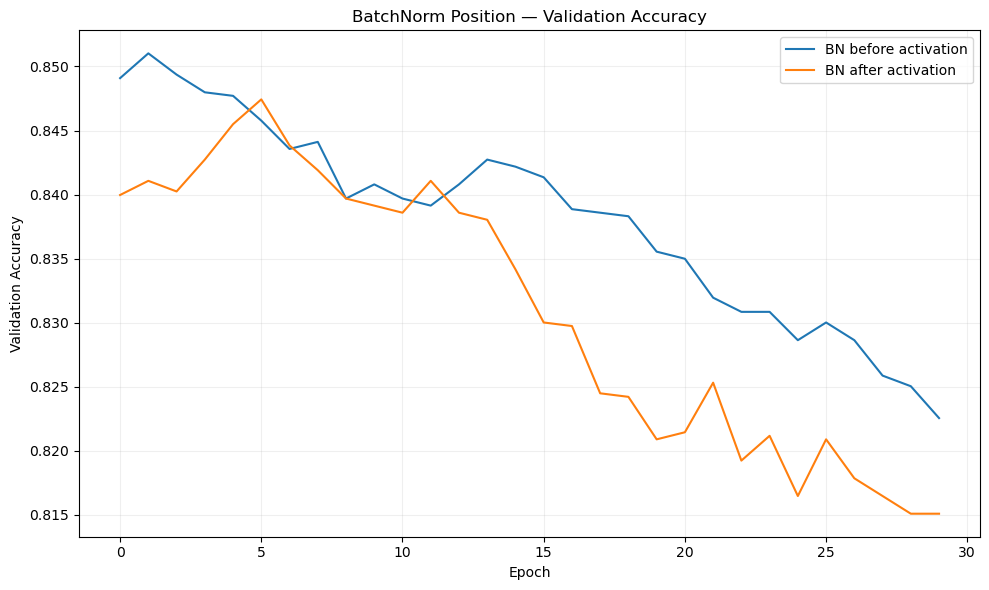

,Model,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC
0,BN before activation,0.817579,0.626496,0.653880,0.639895,0.876249
1,BN after activation,0.809950,0.610105,0.646298,0.627680,0.859152


Descriptive paired t-test across epochs: t=7.841, p=1.2e-08
p < 0.05: True
Caution: this is NOT a formal independent-sample significance test; repeated random seeds are preferable for a publication-level claim.

The common ordering is Dense -> BatchNorm -> Activation because normalization
acts on the linear pre-activation. A single 30-epoch run cannot establish
statistical significance; it only shows empirical performance. For a formal
claim, repeat the experiment with several random seeds and use a paired test.



In [27]:
def build_bn_position_model(position):
    m = keras.Sequential()
    m.add(layers.Input(shape=(X_train.shape[1],)))

    if position == "before":
        # Dense -> BatchNorm -> Activation
        m.add(layers.Dense(128, kernel_initializer="he_normal"))
        m.add(layers.BatchNormalization())
        m.add(layers.Activation("relu"))
        m.add(layers.Dense(64, kernel_initializer="he_normal"))
        m.add(layers.BatchNormalization())
        m.add(layers.Activation("relu"))
    else:
        # Dense -> Activation -> BatchNorm
        m.add(layers.Dense(128, kernel_initializer="he_normal"))
        m.add(layers.Activation("relu"))
        m.add(layers.BatchNormalization())
        m.add(layers.Dense(64, kernel_initializer="he_normal"))
        m.add(layers.Activation("relu"))
        m.add(layers.BatchNormalization())

    m.add(layers.Dense(1, activation="sigmoid"))
    m.compile(optimizer=keras.optimizers.Adam(.001),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m

bn_before = build_bn_position_model("before")
bn_after = build_bn_position_model("after")

hist_before = bn_before.fit(X_train, y_train, epochs=30, batch_size=64,
                            validation_split=.1, verbose=1)
hist_after = bn_after.fit(X_train, y_train, epochs=30, batch_size=64,
                          validation_split=.1, verbose=1)

before_metrics, _, _, _ = add_result(bn_before, "BN before activation")
after_metrics, _, _, _ = add_result(bn_after, "BN after activation")

plt.figure(figsize=(10,6))
plt.plot(hist_before.history["val_accuracy"], label="BN before activation")
plt.plot(hist_after.history["val_accuracy"], label="BN after activation")
plt.title("BatchNorm Position — Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy")
plt.legend(); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

display(pd.DataFrame([before_metrics, after_metrics]))

# Lightweight paired comparison across the 30 validation-accuracy epochs.
# This is descriptive because epochs are not independent observations.
from scipy.stats import ttest_rel
t_stat, p_value = ttest_rel(
    hist_before.history["val_accuracy"],
    hist_after.history["val_accuracy"]
)
print(f"Descriptive paired t-test across epochs: t={t_stat:.3f}, p={p_value:.4g}")
print("p < 0.05:", p_value < 0.05)
print("Caution: this is NOT a formal independent-sample significance test; "
      "repeated random seeds are preferable for a publication-level claim.")

print("""
The common ordering is Dense -> BatchNorm -> Activation because normalization
acts on the linear pre-activation. A single 30-epoch run cannot establish
statistical significance; it only shows empirical performance. For a formal
claim, repeat the experiment with several random seeds and use a paired test.
""")

### Task 6.5 — Inspect learned gamma and beta

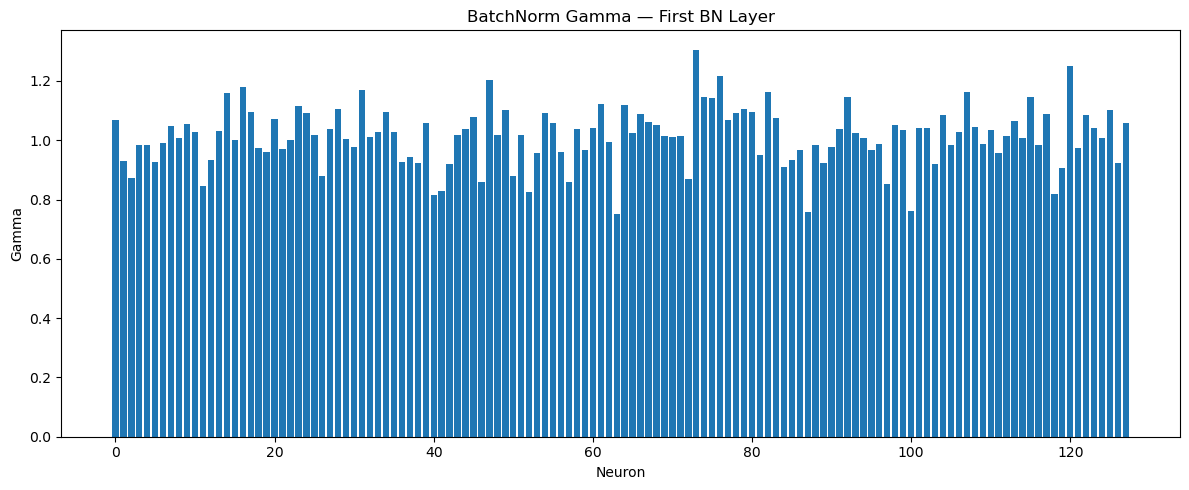

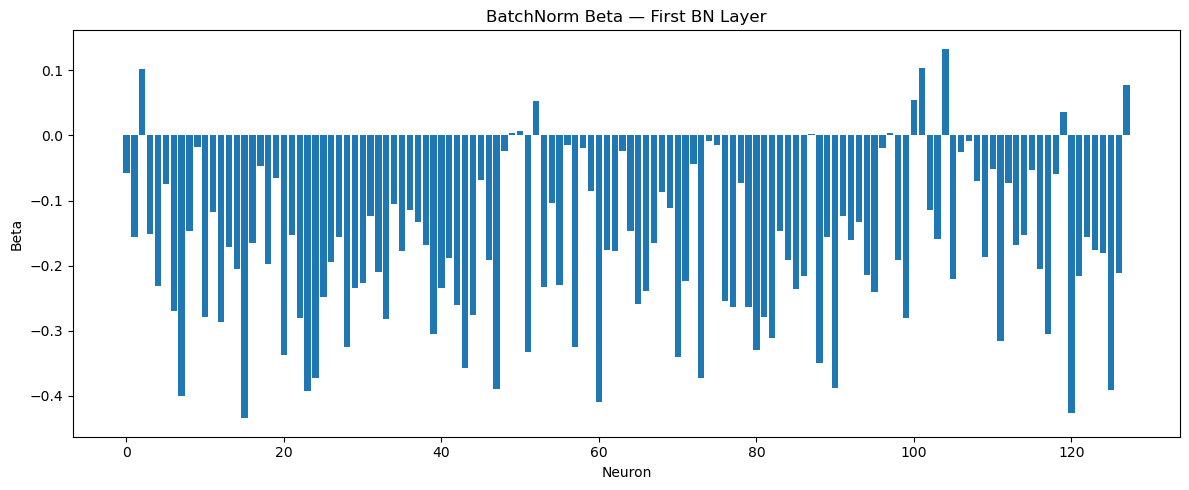

Gamma shape: (128,)
Beta shape: (128,)
Gamma values near zero (|gamma|<=0.05): 0.00%

Gamma controls scale and beta controls shift after normalization. Gamma values
close to zero suppress a feature, while larger absolute gamma values preserve
or amplify it. Thus gamma can be inspected as a rough learned feature-gating
signal.



In [28]:
bn_layer = next(l for l in model_bn.layers
                if isinstance(l, layers.BatchNormalization))
gamma, beta, moving_mean, moving_var = bn_layer.get_weights()

plt.figure(figsize=(12,5))
plt.bar(np.arange(len(gamma)), gamma)
plt.title("BatchNorm Gamma — First BN Layer")
plt.xlabel("Neuron"); plt.ylabel("Gamma")
plt.tight_layout(); plt.show()

plt.figure(figsize=(12,5))
plt.bar(np.arange(len(beta)), beta)
plt.title("BatchNorm Beta — First BN Layer")
plt.xlabel("Neuron"); plt.ylabel("Beta")
plt.tight_layout(); plt.show()

print("Gamma shape:", gamma.shape)
print("Beta shape:", beta.shape)
print("Gamma values near zero (|gamma|<=0.05):",
      f"{np.mean(np.isclose(gamma,0,atol=.05)):.2%}")

print("""
Gamma controls scale and beta controls shift after normalization. Gamma values
close to zero suppress a feature, while larger absolute gamma values preserve
or amplify it. Thus gamma can be inspected as a rough learned feature-gating
signal.
""")

# Task 7 — Optimizers — Convergence & Final Comparison

### Task 7.1 — Build five models with different optimizers

In [29]:
def make_optimizer(name, lr=.001):
    name = name.lower()
    if name == "sgd":
        return keras.optimizers.SGD(learning_rate=lr, momentum=.9)
    if name == "rmsprop":
        return keras.optimizers.RMSprop(learning_rate=lr)
    if name == "adam":
        return keras.optimizers.Adam(learning_rate=lr, beta_1=.9, beta_2=.999)
    if name == "adamax":
        return keras.optimizers.Adamax(learning_rate=lr, beta_1=.9, beta_2=.999)
    if name == "nadam":
        return keras.optimizers.Nadam(learning_rate=lr, beta_1=.9, beta_2=.999)
    raise ValueError(name)

def build_optimizer_model(opt, lr=.001):
    m = build_ann(X_train.shape[1], (128,64), "relu", "he_normal", True)
    m.compile(optimizer=make_optimizer(opt, lr),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m

optimizer_names = ["sgd","rmsprop","adam","adamax","nadam"]
optimizer_models, optimizer_histories = {}, {}

for opt in optimizer_names:
    print("\nTraining:", opt)
    m = build_optimizer_model(opt, .001)
    h = m.fit(X_train, y_train, epochs=50, batch_size=64,
              validation_split=.1, verbose=1)
    optimizer_models[opt] = m
    optimizer_histories[opt] = h
    add_result(m, f"Optimizer - {opt}")


Training: sgd
Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7974 - loss: 0.4366 - val_accuracy: 0.8400 - val_loss: 0.3535
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8418 - loss: 0.3451 - val_accuracy: 0.8466 - val_loss: 0.3378
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8458 - loss: 0.3326 - val_accuracy: 0.8472 - val_loss: 0.3330
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8490 - loss: 0.3261 - val_accuracy: 0.8474 - val_loss: 0.3307
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8508 - loss: 0.3217 - val_accuracy: 0.8488 - val_loss: 0.3292
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8525 - loss: 0.3183 - val_accuracy: 0.8472 - val_loss: 0.3280
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8537 - loss: 0.3156 - val_accuracy: 0.8466 - val_loss: 0.3274
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8549 - loss: 0.3133 - v

### Task 7.2 — Optimizer convergence plot

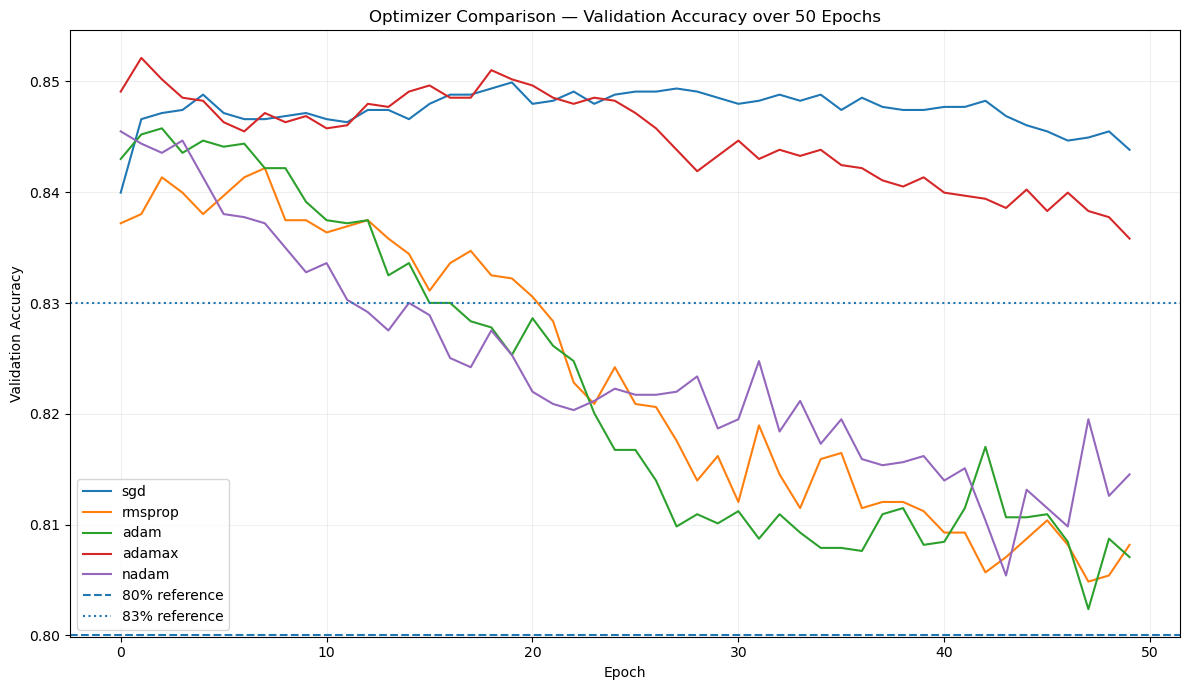

sgd: final val accuracy = 0.8438
rmsprop: final val accuracy = 0.8082
adam: final val accuracy = 0.8071
adamax: final val accuracy = 0.8358
nadam: final val accuracy = 0.8145


In [30]:
plt.figure(figsize=(12,7))
for opt in optimizer_names:
    plt.plot(optimizer_histories[opt].history["val_accuracy"], label=opt)
plt.axhline(.80, linestyle="--", label="80% reference")
plt.axhline(.83, linestyle=":", label="83% reference")
plt.title("Optimizer Comparison — Validation Accuracy over 50 Epochs")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy")
plt.legend(); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

for opt in optimizer_names:
    print(f"{opt}: final val accuracy = "
          f"{optimizer_histories[opt].history['val_accuracy'][-1]:.4f}")

### Task 7.3 — WHY Adam dominates

| Optimizer | Main idea | Strength | Weakness |
|---|---|---|---|
| Vanilla SGD | Fixed-step gradient descent | Simple, low memory | Slow / learning-rate sensitive |
| SGD + Momentum | Adds velocity | Smooths oscillations | Still needs tuning |
| RMSProp | Running average of squared gradients | Adaptive per-parameter steps | Hyperparameter sensitivity |
| Adam | Momentum + adaptive second moment | Fast, robust default | More state / not always best generalizer |
| Adamax | Infinity-norm Adam variant | Stable adaptive updates | Often no advantage over Adam |
| Nadam | Adam + Nesterov-style momentum | Adaptive + anticipatory momentum | More complexity |

Adam often works very well here because one-hot tabular features can generate gradients with different scales. Its first- and second-moment estimates produce parameter-wise adaptive updates. **However, Adam is not universally best**; the experiment's validation/test F1 and ROC-AUC should decide.

### Task 7.4 — Learning-rate sensitivity: SGD vs Adam


Training: SGD_lr=0.0001
Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6672 - loss: 0.6207 - val_accuracy: 0.7344 - val_loss: 0.5210
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7635 - loss: 0.4945 - val_accuracy: 0.7833 - val_loss: 0.4644
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7970 - loss: 0.4469 - val_accuracy: 0.8107 - val_loss: 0.4268
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8133 - loss: 0.4185 - val_accuracy: 0.8184 - val_loss: 0.4028
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8217 - loss: 0.3998 - val_accuracy: 0.8256 - val_loss: 0.3868
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8274 - loss: 0.3868 - val_accuracy: 0.8317 - val_loss: 0.3755
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8308 - loss: 0.3774 - val_accuracy: 0.8353 - val_loss: 0.3673
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8343 - loss: 

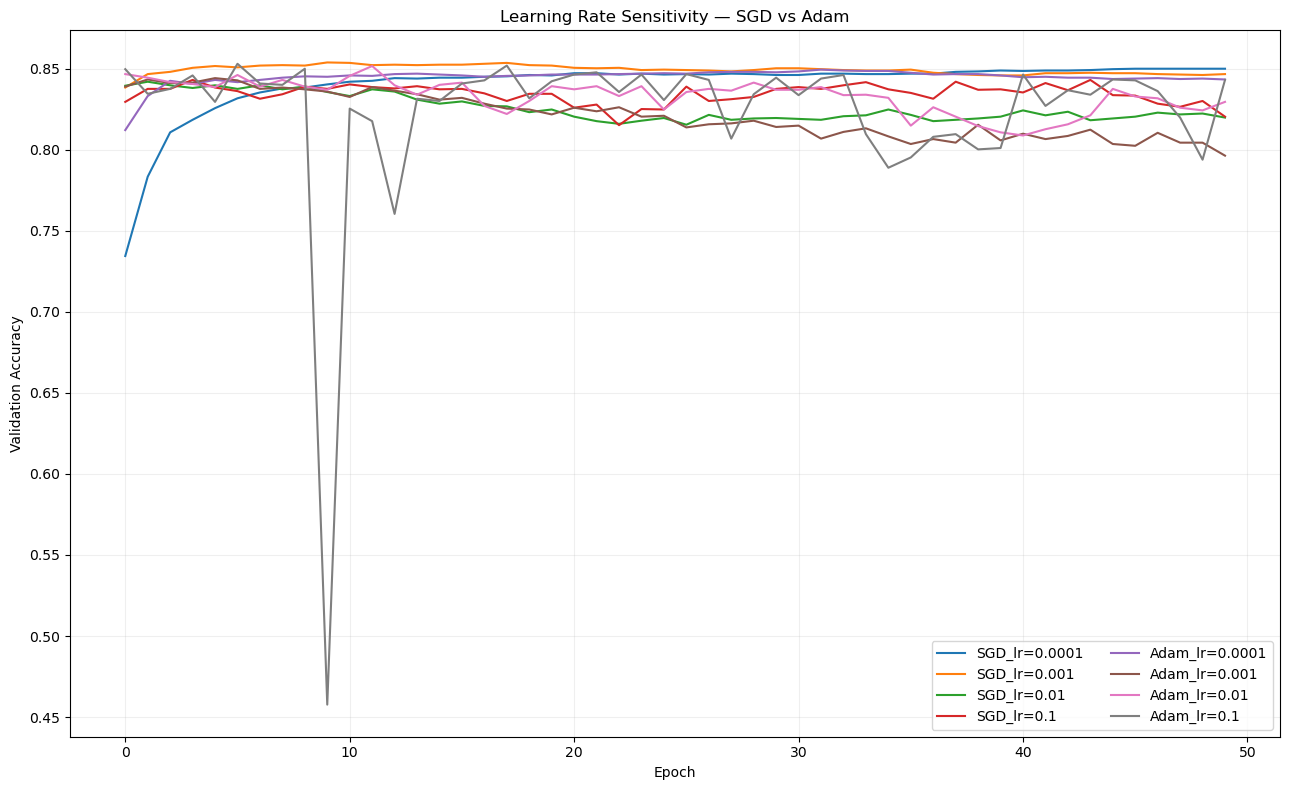

,Configuration,Final Val Accuracy,Best Val Accuracy
1,SGD_lr=0.001,0.846600,0.853787
7,Adam_lr=0.1,0.843007,0.852957
6,Adam_lr=0.01,0.829464,0.851575
0,SGD_lr=0.0001,0.849917,0.849917
4,Adam_lr=0.0001,0.843284,0.849364
5,Adam_lr=0.001,0.796296,0.844113
3,SGD_lr=0.1,0.820343,0.843007
2,SGD_lr=0.01,0.819790,0.841902


In [31]:
# The sheet says "7 models", but the listed rates imply 4 SGD + 4 Adam = 8.
# We implement all eight listed configurations so no requested rate is omitted.

lr_values = [.0001, .001, .01, .1]
lr_models, lr_histories = {}, {}

for opt in ["SGD","Adam"]:
    for lr in lr_values:
        key = f"{opt}_lr={lr}"
        print("\nTraining:", key)
        m = build_optimizer_model(opt.lower(), lr)
        h = m.fit(X_train, y_train, epochs=50, batch_size=64,
                  validation_split=.1, verbose=1)
        lr_models[key] = m
        lr_histories[key] = h
        add_result(m, f"LR - {key}")

plt.figure(figsize=(13,8))
for key, h in lr_histories.items():
    plt.plot(h.history["val_accuracy"], label=key)
plt.title("Learning Rate Sensitivity — SGD vs Adam")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy")
plt.legend(ncol=2); plt.grid(alpha=.2)
plt.tight_layout(); plt.show()

lr_summary = pd.DataFrame([
    [k, h.history["val_accuracy"][-1], max(h.history["val_accuracy"])]
    for k,h in lr_histories.items()
], columns=["Configuration","Final Val Accuracy","Best Val Accuracy"])
display(lr_summary.sort_values("Best Val Accuracy", ascending=False))

**Interpretation:** SGD usually becomes very slow at extremely small learning rates and can oscillate/diverge at overly large rates. Adam is often more tolerant because its update is adaptive, but very large learning rates can still destabilize it.

### Task 7.5 — Final Combined ANN — best configuration

Loss candidates:


weighted_bce           0.647615
binary_crossentropy    0.630904
focal                  0.541804
dtype: float64

Selected loss: weighted_bce
Epoch 1/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7940 - loss: 0.4085 - val_accuracy: 0.8046 - val_loss: 0.3940
Epoch 2/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8122 - loss: 0.3731 - val_accuracy: 0.8062 - val_loss: 0.3848
Epoch 3/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8189 - loss: 0.3619 - val_accuracy: 0.8087 - val_loss: 0.3771
Epoch 4/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8230 - loss: 0.3531 - val_accuracy: 0.8060 - val_loss: 0.3799
Epoch 5/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8266 - loss: 0.3449 - val_accuracy: 0.8087 - val_loss: 0.3814
Epoch 6/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8314 - loss: 0.3363 - val_accuracy: 0.8085 - val_loss: 0.3838
Epoch 7/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8352 - loss: 0.3279 - val_accuracy: 0.8076 - val_loss: 0.3877
Epoch 8/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8388 - los

,Model,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC
0,Final Combined ANN,0.806855,0.606178,0.630241,0.617975,0.853245


{'Activation': 'relu', 'Hidden units': [128, 64], 'Initializer': 'he_normal', 'BatchNorm': True, 'Optimizer': 'Adam', 'Loss': 'Weighted BCE', 'Epochs': 80}


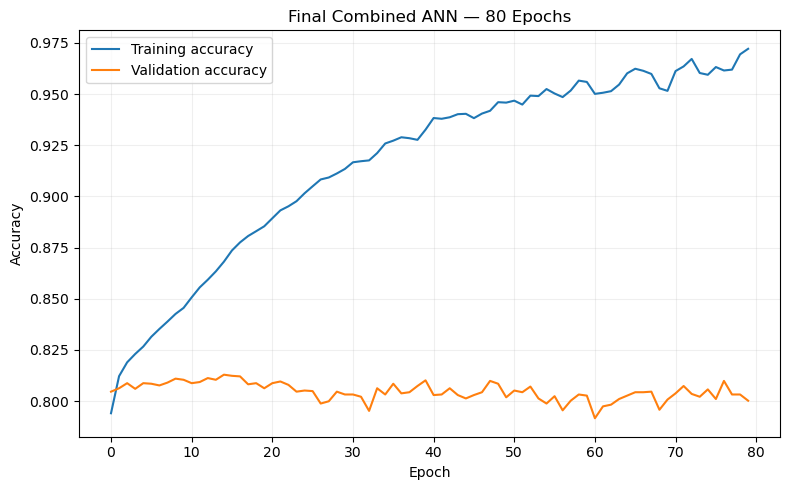

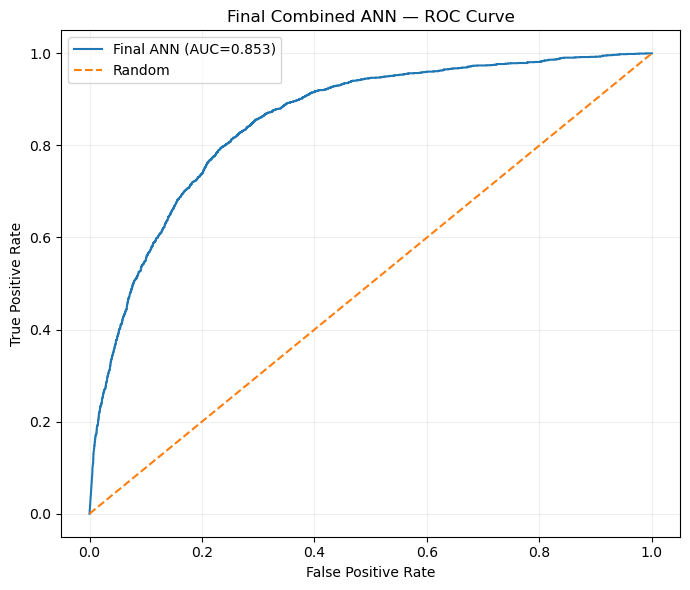

In [32]:
# Choose the loss that produced the strongest minority-class F1 in Task 5.
loss_candidates = {
    "binary_crossentropy": base_metrics["F1_1"],
    "weighted_bce": wbce_metrics["F1_1"],
    "focal": focal_metrics["F1_1"]
}
best_loss_name = max(loss_candidates, key=loss_candidates.get)
print("Loss candidates:")
display(pd.Series(loss_candidates).sort_values(ascending=False))
print("Selected loss:", best_loss_name)

final_model = build_ann(
    X_train.shape[1],
    hidden_units=(128,64),
    activation="relu",
    initializer="he_normal",
    batch_norm=True
)

if best_loss_name == "focal":
    final_loss = focal_loss(2.0, .25)
    final_loss_label = "Focal"
elif best_loss_name == "weighted_bce":
    final_loss = "binary_crossentropy"
    final_loss_label = "Weighted BCE"
else:
    final_loss = "binary_crossentropy"
    final_loss_label = "BCE"

final_model.compile(
    optimizer=keras.optimizers.Adam(.001),
    loss=final_loss, metrics=["accuracy"]
)

fit_kwargs = {"class_weight": class_weight} if best_loss_name=="weighted_bce" else {}

history_final = final_model.fit(
    X_train, y_train, epochs=80, batch_size=64,
    validation_split=.1, verbose=1, **fit_kwargs
)

final_metrics, final_cm, final_prob, final_pred = add_result(
    final_model, "Final Combined ANN"
)
display(pd.DataFrame([final_metrics]))

print({
    "Activation":"relu", "Hidden units":[128,64],
    "Initializer":"he_normal", "BatchNorm":True,
    "Optimizer":"Adam", "Loss":final_loss_label, "Epochs":80
})

plot_history(history_final, "Final Combined ANN — 80 Epochs")

fpr, tpr, _ = roc_curve(y_test, final_prob)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"Final ANN (AUC={final_metrics['ROC_AUC']:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Final Combined ANN — ROC Curve")
plt.legend(); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

### Task 7.6 — Full results comparison

In [33]:
full = results_df().copy().rename(columns={
    "Precision_1":"Prec(1)",
    "Recall_1":"Recall(1)",
    "F1_1":"F1(1)",
    "ROC_AUC":"ROC-AUC",
    "Accuracy":"Test Acc"
})

def metadata(name):
    # Defaults
    activation, init, loss, bn, opt = "relu","he_normal","BCE","No","Adam"

    if name == "Baseline ANN":
        init = "glorot_uniform"
    elif name.startswith("Activation - "):
        activation = name.split(" - ",1)[1]; init = "glorot_uniform"
    elif name.startswith("Initializer - "):
        init = name.split(" - ",1)[1]
    elif name == "MSE loss":
        loss = "MSE"
    elif name == "Weighted BCE":
        loss = "Weighted BCE"
    elif name == "Focal Loss":
        loss = "Focal"
    elif name == "BatchNorm ANN":
        bn = "Yes"
    elif name.startswith("BN "):
        bn = "Yes"
    elif name.startswith("Optimizer - "):
        opt = name.split(" - ",1)[1]
        bn = "Yes"
    elif name.startswith("LR - "):
        opt = name.split(" - ",1)[1].split("_")[0]
        bn = "Yes"
    elif name == "Final Combined ANN":
        loss = final_loss_label; bn = "Yes"
    return activation, init, loss, bn, opt

meta = full["Model"].apply(metadata)
full[["Activation","Init","Loss","BatchNorm","Optimizer"]] = pd.DataFrame(
    meta.tolist(), index=full.index
)

full = full[[
    "Model","Activation","Init","Loss","BatchNorm","Optimizer",
    "Test Acc","Prec(1)","Recall(1)","F1(1)","ROC-AUC"
]]

display(full.sort_values("F1(1)", ascending=False).reset_index(drop=True))

best = full.loc[full["F1(1)"].idxmax()]
print("Best model by minority-class F1:")
display(pd.DataFrame([best]))

,Model,Activation,Init,Loss,BatchNorm,Optimizer,Test Acc,Prec(1),Recall(1),F1(1),ROC-AUC
0,Activation - sigmoid,sigmoid,glorot_uniform,BCE,No,Adam,0.854505,0.744715,0.628457,0.681664,0.911341
1,Optimizer - sgd,relu,he_normal,BCE,Yes,sgd,0.844334,0.712538,0.623550,0.665081,0.899107
2,Activation - elu,elu,glorot_uniform,BCE,No,Adam,0.845329,0.718055,0.619090,0.664910,0.900388
3,LR - SGD_lr=0.1,relu,he_normal,BCE,Yes,SGD,0.816584,0.608003,0.731936,0.664238,0.883307
4,Activation - tanh,tanh,glorot_uniform,BCE,No,Adam,0.843118,0.713102,0.614184,0.659957,0.898955
5,LR - SGD_lr=0.001,relu,he_normal,BCE,Yes,SGD,0.842565,0.710825,0.615076,0.659493,0.897957
6,LR - Adam_lr=0.0001,relu,he_normal,BCE,Yes,Adam,0.841902,0.711458,0.609277,0.656415,0.899696
7,LR - SGD_lr=0.0001,relu,he_normal,BCE,Yes,SGD,0.844444,0.725310,0.599465,0.656410,0.902322
8,Weighted BCE,relu,he_normal,Weighted BCE,No,Adam,0.798231,0.570991,0.747993,0.647615,0.873434
9,Optimizer - adamax,relu,he_normal,BCE,Yes,adamax,0.831399,0.672108,0.624442,0.647399,0.880806


Best model by minority-class F1:


,Model,Activation,Init,Loss,BatchNorm,Optimizer,Test Acc,Prec(1),Recall(1),F1(1),ROC-AUC
3,Activation - sigmoid,sigmoid,glorot_uniform,BCE,No,Adam,0.854505,0.744715,0.628457,0.681664,0.911341


## Final conclusions for the report / viva

- **Preprocessing:** clean `?`, remove incomplete rows, drop `fnlwgt`, encode the target, one-hot encode categoricals, scale continuous numeric variables, and use a stratified split.
- **Baseline:** `128 → 64 → 1`, ReLU hidden layers, sigmoid output, Glorot initialization, Adam, BCE.
- **Activation:** ReLU is generally preferable for hidden layers because it avoids the strong saturation of sigmoid and preserves gradients on positive inputs.
- **Initialization:** all-zero weights fail due to symmetry; Glorot/He break symmetry, with He particularly suited to ReLU.
- **Loss:** BCE is the natural binary loss; Weighted BCE and Focal Loss are useful for the roughly 75/25 class imbalance.
- **BatchNorm:** stabilizes intermediate activation distributions and often improves convergence.
- **Optimizer:** Adam is a strong practical default, but the experiment should be judged by minority-class F1 and ROC-AUC as well as accuracy.
- **Final comparison:** Task 7.6 provides the requested single results table for model, activation, initialization, loss, BatchNorm, optimizer, accuracy, precision, recall, F1, and ROC-AUC.